# Progetto parte 2 del corso di "Data Mining" da 12 CFU

### MODULE 3: Motifs / Discords

*TIME SERIES DATASET STANDARDIZED*
* Analyse the dataset for finding motifs and/or anomalies.
* Visualize and discuss them and their relationship with shapelets.

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.


In [1]:
# Import librerie standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import stumpy
from tslearn.shapelets import ShapeletModel
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Import per time series
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
# Stile base
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="icefire",
    font="sans-serif",
    font_scale=1.1
)

# Aggiornamenti avanzati
plt.rcParams.update({
    # Colori e sfondi
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'axes.titlecolor': 'white',
    'text.color': 'white',
    'xtick.color': 'lightgray',
    'ytick.color': 'lightgray',

    # Font e peso
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',

    # Griglia elegante
    'axes.grid': True,
    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.linewidth': 0.4,
    'grid.alpha': 0.3,  # meno invasiva

    # Tick leggeri
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Leggibilità generale
    'legend.edgecolor': 'gray',
    'legend.facecolor': '#222222',
    'legend.fontsize': 'medium',
})

# plt.style.use('seaborn-v0_8-darkgrid')
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10

print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I MODELLI ---
print("--- Creazione directory per i modelli ---")
models_dir = 'models_time_series_understanding/'
os.makedirs(models_dir, exist_ok=True)
print(f"✅ Directory per i modelli '{models_dir}' pronta.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_time_series_motifs_discords/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = "TS_Dataset/"
dataset_name = "imdb_ts.csv"
try:
    df = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {df.shape[0]} righe, {df.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)



✅ Impostazioni grafiche caricate.
--- Creazione directory per i modelli ---
✅ Directory per i modelli 'models_time_series_understanding/' pronta.
✅ Directory per i grafici 'plots_time_series_motifs_discords/' pronta.
✅ Dataset preparato caricato: 1134 righe, 104 colonne.


In [2]:
df

,id,0,1,2,3,4,5,6,7,8,...,93,94,95,96,97,98,99,rating,genre,rating_category
0,tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,...,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0,8.3,"['Adventure', 'Sci-Fi']",High
1,tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,...,637.0,734.0,857.0,785.0,724.0,713.0,699.0,7.1,"['Crime', 'Drama', 'Romance']",High
2,tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,...,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0,8.7,"['Documentary', 'Music']",High
3,tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,...,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0,7.4,"['Action', 'Adventure', 'Sci-Fi']",High
4,tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,...,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0,7.3,"['Adventure', 'Comedy', 'Drama']",High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,tt9731534,1077363.0,1061148.0,1043451.0,912840.0,738595.0,508118.0,296236.0,318113.0,341113.0,...,2396.0,2425.0,2461.0,2223.0,1920.0,1991.0,2051.0,6.4,"['Horror', 'Mystery', 'Thriller']",Medium
1130,tt9735462,56775.0,57750.0,58828.0,53549.0,48484.0,37340.0,19243.0,30804.0,55897.0,...,739.0,618.0,488.0,636.0,883.0,904.0,920.0,6.3,"['Biography', 'Comedy', 'Drama']",Medium
1131,tt9764362,3595005.0,3401235.0,3221227.0,2645775.0,2188725.0,1681250.0,1030698.0,1138724.0,1290788.0,...,345246.0,257388.0,182883.0,165311.0,144119.0,128009.0,111756.0,7.2,"['Comedy', 'Horror', 'Thriller']",High
1132,tt9784798,528167.0,617409.0,696127.0,741481.0,802782.0,527997.0,177249.0,141753.0,100026.0,...,10108.0,10511.0,10878.0,7491.0,3752.0,5237.0,6592.0,7.4,"['Biography', 'Drama', 'History']",High


### Preparazione dei dati

In [3]:
# Sostituisci la colonna 'id' con numeri da 1 a N
df['id'] = range(1, len(df) + 1)

# Definizione esatta delle colonne come da accordi
metadata_cols = ['id', 'rating', 'genre', 'rating_category']
ts_cols = [col for col in df.columns if col not in metadata_cols]

# Separazione dei dati in metadati e serie storiche
metadata = df[metadata_cols]
time_series_data = df[ts_cols].to_numpy()

# Standardizzazione con StandardScaler (applicata a ogni serie storica/riga)
scaler = StandardScaler()
# Per standardizzare ogni riga, trasponiamo i dati, applichiamo lo scaler,
# e poi trasponiamo di nuovo il risultato.
ts_std = scaler.fit_transform(time_series_data.T).T
print(f"Normalized data - Mean: {ts_std.mean():.3f}, Std: {ts_std.std():.3f}")

print("\nStandardizzazione completata utilizzando StandardScaler.")
print(f"Shape dei dati pronti per l'analisi: {ts_std.shape}")
print(f"Numero di serie storiche: {ts_std.shape[0]}")
print(f"Lunghezza di ogni serie storica: {ts_std.shape[1]}")

Normalized data - Mean: 0.000, Std: 1.000

Standardizzazione completata utilizzando StandardScaler.
Shape dei dati pronti per l'analisi: (1134, 100)
Numero di serie storiche: 1134
Lunghezza di ogni serie storica: 100


#### CALCOLO DEL PAN MATRIX PROFILE

In [4]:
# =================================================================================
# CELLA 2: CALCOLO DEL MATRIX PROFILE GLOBALE
# =================================================================================

# --- OBIETTIVO ---
# Identificare il motivo (pattern più comune) e la discordanza (anomalia più significativa)
# all'interno dell'intero dataset di serie storiche.
#
# --- METODOLOGIA ---
# 1. Si concatenano tutte le serie storiche standardizzate (ts_std) in un'unica
#    mega-serie. Le singole serie sono separate da una sequenza di NaN per
#    prevenire l'identificazione di falsi pattern tra serie adiacenti.
# 2. Si calcola il Matrix Profile su questa mega-serie usando l'algoritmo STUMP.
# 3. Si identificano il minimo (motivo) e il massimo (discordanza) nel profilo calcolato.
# 4. Gli indici ottenuti vengono mappati nuovamente alle loro posizioni originali.
#
# --- PARAMETRI CHIAVE ---
m = 15  # Lunghezza della sotto-sequenza (finestra) da analizzare.

# ---------------------------------------------------------------------------------

# 1. PREPARAZIONE DELLA SERIE CONCATENATA
# ---------------------------------------------------------------------------------
print("--- [Step 1/4] Preparazione della serie concatenata ---")

# Creiamo un separatore di NaN per isolare le serie
separator = np.full(m, np.nan)
all_series = []
for i in range(ts_std.shape[0]):
    all_series.append(ts_std[i])
    # Aggiungi il separatore tranne che dopo l'ultima serie
    if i < ts_std.shape[0] - 1:
        all_series.append(separator)

concatenated_ts = np.concatenate(all_series).astype(np.float64)
print(f"✅ Serie concatenata creata (lunghezza totale: {len(concatenated_ts)}).")


# 2. CALCOLO DEL MATRIX PROFILE
# ---------------------------------------------------------------------------------
print("\n--- [Step 2/4] Calcolo del Matrix Profile in corso... ---")
start_time = time.time()

try:
    # Eseguiamo l'algoritmo STUMP sulla serie unica
    mp = stumpy.stump(concatenated_ts, m=m)
    end_time = time.time()
    print(f"✅ Calcolo completato in {end_time - start_time:.2f} secondi.")

except Exception as e:
    print(f"❌ ERRORE durante il calcolo del Matrix Profile: {e}")
    print("   Questo può accadere con dataset molto grandi. Considera di ridurre il numero di serie per il test.")
    mp = None # Assicura che mp esista per evitare errori successivi


# 3. FUNZIONE DI MAPPING DEGLI INDICI
# ---------------------------------------------------------------------------------
def get_original_indices(idx, original_len, separator_len):
    """
    Converte un indice dalla serie concatenata alla sua posizione originale
    restituendo l'indice della serie e l'indice della sotto-sequenza.
    """
    if idx is None or np.isnan(idx):
        return None, None
    block_size = original_len + separator_len
    ts_idx = int(idx // block_size)
    sub_idx = int(idx % block_size)
    return ts_idx, sub_idx

original_series_len = ts_std.shape[1]
print("\n--- [Step 3/4] Funzione di mapping pronta ---")


# 4. ESTRAZIONE E PRESENTAZIONE DEI RISULTATI
# ---------------------------------------------------------------------------------
print("\n--- [Step 4/4] Estrazione dei risultati ---")
if mp is not None:
    # Estrazione del Motivo Globale
    motif_idx = np.argmin(mp[:, 0])
    neighbor_idx = mp[motif_idx, 1]
    motif_ts_idx, motif_sub_idx = get_original_indices(motif_idx, original_series_len, m)
    neighbor_ts_idx, neighbor_sub_idx = get_original_indices(neighbor_idx, original_series_len, m)

    print("\n--- MOTIVO GLOBALE (Pattern più comune) ---")
    print(f"  - Posizione Pattern: Serie #{motif_ts_idx} (ID: {metadata.loc[motif_ts_idx, 'id']}), Indice: {motif_sub_idx}")
    print(f"  - Posizione Vicino:  Serie #{neighbor_ts_idx} (ID: {metadata.loc[neighbor_ts_idx, 'id']}), Indice: {neighbor_sub_idx}")
    print(f"  - Distanza (Minima): {mp[motif_idx, 0]:.4f}")

    # Estrazione della Discordanza Globale
    discord_idx = np.argmax(mp[:, 0])
    discord_ts_idx, discord_sub_idx = get_original_indices(discord_idx, original_series_len, m)

    print("\n--- DISCORDANZA GLOBALE (Anomalia) ---")
    print(f"  - Posizione Anomalia: Serie #{discord_ts_idx} (ID: {metadata.loc[discord_ts_idx, 'id']}), Indice: {discord_sub_idx}")
    print(f"  - Distanza (Massima):  {mp[discord_idx, 0]:.4f}")
else:
    print("❌ Calcolo del Matrix Profile non riuscito. Impossibile estrarre i risultati.")
    exit(1)

--- [Step 1/4] Preparazione della serie concatenata ---
✅ Serie concatenata creata (lunghezza totale: 130395).

--- [Step 2/4] Calcolo del Matrix Profile in corso... ---
✅ Calcolo completato in 10.49 secondi.

--- [Step 3/4] Funzione di mapping pronta ---

--- [Step 4/4] Estrazione dei risultati ---

--- MOTIVO GLOBALE (Pattern più comune) ---
  - Posizione Pattern: Serie #420 (ID: 421), Indice: 31
  - Posizione Vicino:  Serie #774 (ID: 775), Indice: 33
  - Distanza (Minima): 0.0070

--- DISCORDANZA GLOBALE (Anomalia) ---
  - Posizione Anomalia: Serie #0 (ID: 1), Indice: 86
  - Distanza (Massima):  inf


#### Visualizzazione dei Risultati

--- [1/3] Creazione del grafico per il Motivo Globale ---


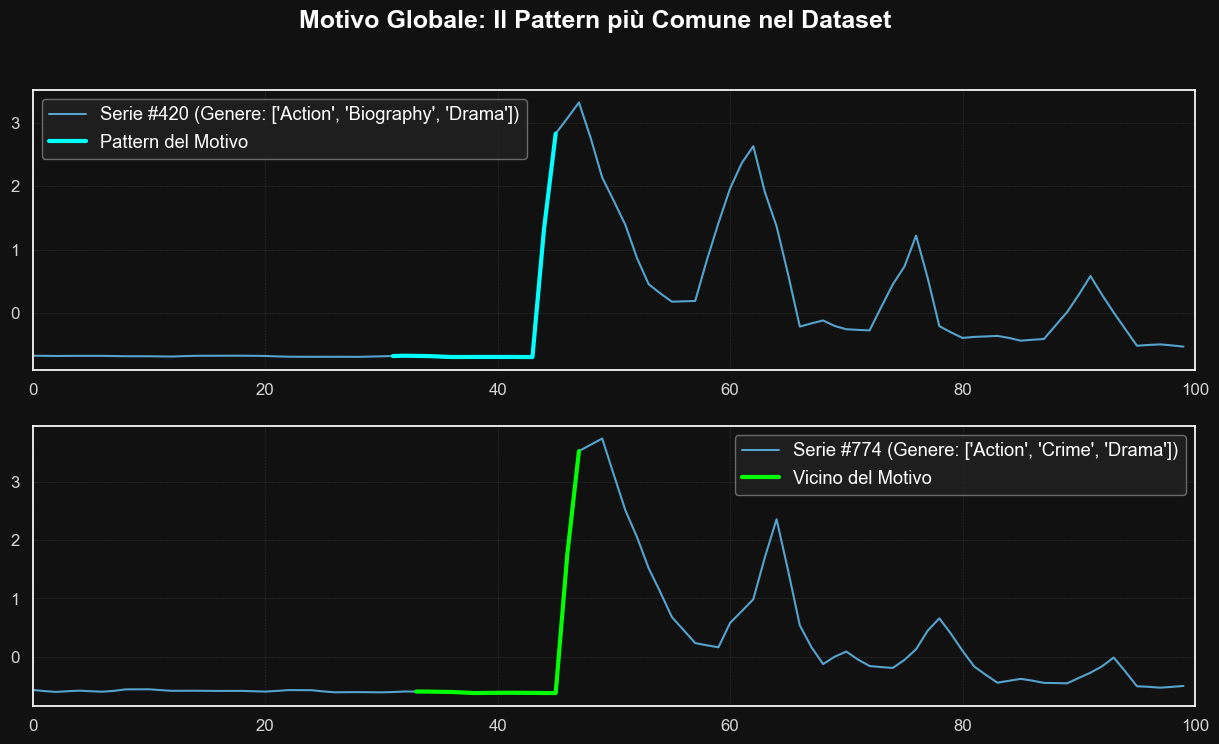

✅ Grafico del motivo salvato in: plots_time_series_motifs_discords/global_motif.png

--- [2/3] Creazione del grafico di confronto con la Time Series Media ---


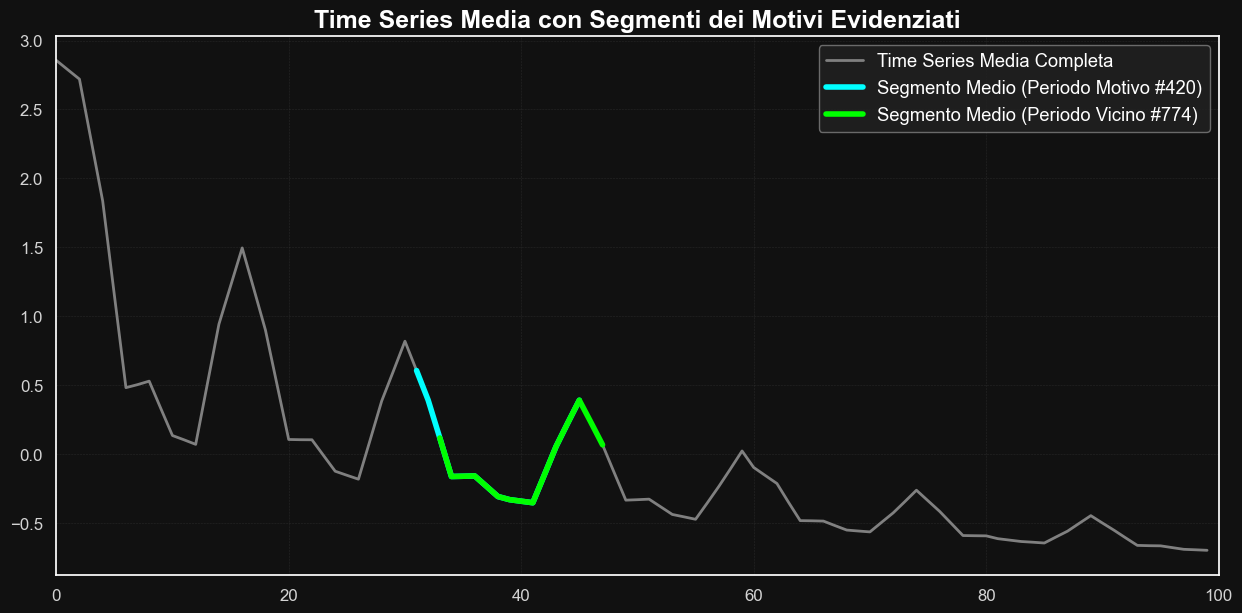

✅ Grafico con segmenti evidenziati salvato in: plots_time_series_motifs_discords/mean_with_motif_segments.png

--- [3/3] Creazione del grafico per la Discordanza Globale ---


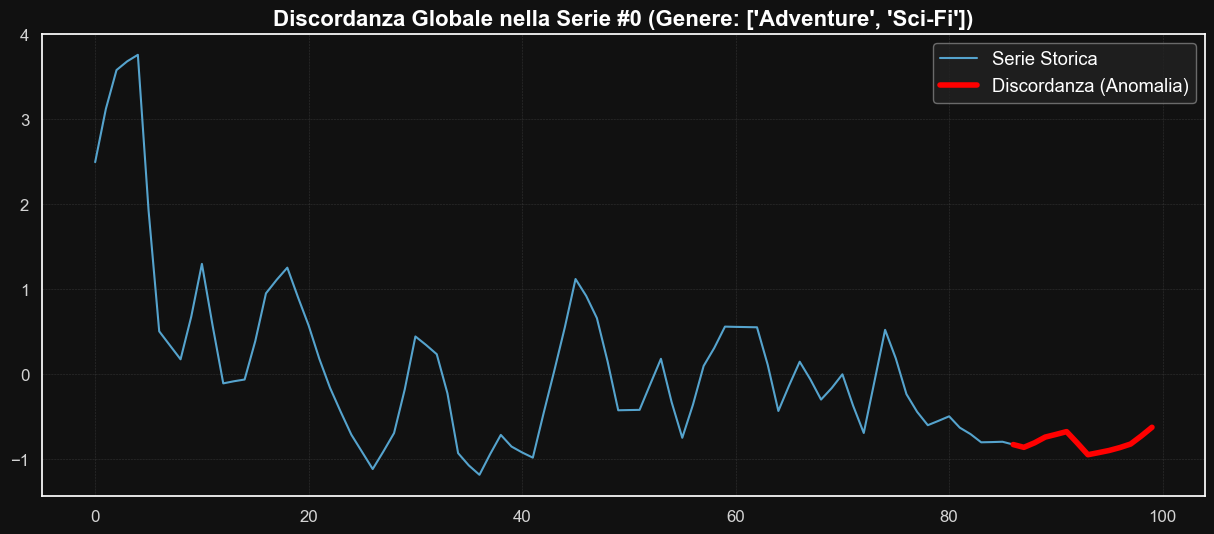

✅ Grafico della discordanza salvato in: plots_time_series_motifs_discords/global_discord.png


In [5]:
# ========================
# CELLA 3: VISUALIZZAZIONE
# ========================

# 1. VISUALIZZAZIONE DEL MOTIVO GLOBALE (CON FIX DEFINITIVO)
# ---------------------------------------------------------------------------------
print("--- [1/3] Creazione del grafico per il Motivo Globale ---")

# --- SOLUZIONE DEFINITIVA: Rimuoviamo sharex e controlliamo manualmente ogni asse ---
fig, axs = plt.subplots(2, 1, figsize=(15, 8)) # NIENTE PIÙ sharex
plt.suptitle('Motivo Globale: Il Pattern più Comune nel Dataset', fontsize=18, weight='bold')

# --- Plot del pattern originale (axs[0]) ---
motif_slice = ts_std[motif_ts_idx, motif_sub_idx:motif_sub_idx + m]
axs[0].plot(ts_std[motif_ts_idx], label=f"Serie #{motif_ts_idx} (Genere: {metadata.loc[motif_ts_idx, 'genre']})")
axs[0].plot(range(motif_sub_idx, motif_sub_idx + len(motif_slice)),
            motif_slice, color='cyan', lw=3, label='Pattern del Motivo')
axs[0].legend()
# Forziamo il limite dell'asse X per mostrare la serie completa
axs[0].set_xlim(0, ts_std.shape[1])

# --- Plot del suo vicino più prossimo (axs[1]) ---
neighbor_slice = ts_std[neighbor_ts_idx, neighbor_sub_idx:neighbor_sub_idx + m]
axs[1].plot(ts_std[neighbor_ts_idx], label=f"Serie #{neighbor_ts_idx} (Genere: {metadata.loc[neighbor_ts_idx, 'genre']})")
axs[1].plot(range(neighbor_sub_idx, neighbor_sub_idx + len(neighbor_slice)),
             neighbor_slice, color='lime', lw=3, label='Vicino del Motivo')
axs[1].legend()
# Forziamo il limite dell'asse X anche qui
axs[1].set_xlim(0, ts_std.shape[1])

# Salvataggio del grafico
motif_plot_path = os.path.join(plots_dir, 'global_motif.png')
plt.savefig(motif_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico del motivo salvato in: {motif_plot_path}")


# 2. VISUALIZZAZIONE DEI MOTIVI SULLA TIME SERIES MEDIA
# ---------------------------------------------------------------------------------
print("\n--- [2/3] Creazione del grafico di confronto con la Time Series Media ---")

# Calcoliamo la media
mean_ts = ts_std.mean(axis=0)
plt.figure(figsize=(15, 7))
plt.title('Time Series Media con Segmenti dei Motivi Evidenziati', fontsize=18, weight='bold')

# Disegniamo l'intera time series media
plt.plot(mean_ts, color='gray', lw=2, label='Time Series Media Completa')

# Evidenziamo i segmenti della media corrispondenti ai motivi
motif_window_on_mean = mean_ts[motif_sub_idx : motif_sub_idx + m]
plt.plot(range(motif_sub_idx, motif_sub_idx + len(motif_window_on_mean)),
         motif_window_on_mean, color='cyan', lw=4, label=f'Segmento Medio (Periodo Motivo #{motif_ts_idx})')

neighbor_window_on_mean = mean_ts[neighbor_sub_idx : neighbor_sub_idx + m]
plt.plot(range(neighbor_sub_idx, neighbor_sub_idx + len(neighbor_window_on_mean)),
         neighbor_window_on_mean, color='lime', lw=4, label=f'Segmento Medio (Periodo Vicino #{neighbor_ts_idx})')

plt.xlim(0, ts_std.shape[1])
plt.legend()
plt.grid(True, alpha=0.2)
# Salvataggio del grafico
mean_motif_plot_path = os.path.join(plots_dir, 'mean_with_motif_segments.png')
plt.savefig(mean_motif_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico con segmenti evidenziati salvato in: {mean_motif_plot_path}")


# 3. VISUALIZZAZIONE DELLA DISCORDANZA GLOBALE
# ---------------------------------------------------------------------------------
print("\n--- [3/3] Creazione del grafico per la Discordanza Globale ---")

plt.figure(figsize=(15, 6))
plt.title(f'Discordanza Globale nella Serie #{discord_ts_idx} (Genere: {metadata.loc[discord_ts_idx, "genre"]})', fontsize=16, weight='bold')
plt.plot(ts_std[discord_ts_idx], label='Serie Storica')
discord_slice = ts_std[discord_ts_idx, discord_sub_idx:discord_sub_idx + m]
x_range_discord = range(discord_sub_idx, discord_sub_idx + len(discord_slice))
plt.plot(x_range_discord, discord_slice, color='red', lw=4, label='Discordanza (Anomalia)')
plt.legend()
# Salvataggio del grafico
discord_plot_path = os.path.join(plots_dir, 'global_discord.png')
plt.savefig(discord_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico della discordanza salvato in: {discord_plot_path}")

In [6]:
#### SHAPELETES DISCOVERY PER IL MOTIF-LIKE e valutazione

--- [Step 1/5] Preparazione dati per l'analisi Shapelet ---
✅ Etichetta 'motif_like' creata per i generi ['Action', 'Drama'].

--- [Step 2/5] Preparazione di X e y per il modello ---
   Distribuzione: {0: 1053, 1: 81}

--- [Step 3/5] Addestramento del modello Shapelet in corso... ---


2025-07-31 15:09:24.518162: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-07-31 15:09:24.518194: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-07-31 15:09:24.518203: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-07-31 15:09:24.518216: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-31 15:09:24.518224: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-07-31 15:10:30.882754: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


✅ Addestramento completato in 76.91 secondi.

--- [Step 4/5] Valutazione delle performance del modello ---

--- Matrice di Confusione ---
Spiegazione (riga=Reale, colonna=Previsto):
        | Prev. Non-Motif | Prev. Motif-Like |
Reale Non-Motif |    1053         |    0             |
Reale Motif-Like|    81           |    0             |

--- Report di Classificazione ---
                precision    recall  f1-score   support

Non-Motif-Like       0.93      1.00      0.96      1053
    Motif-Like       0.00      0.00      0.00        81

      accuracy                           0.93      1134
     macro avg       0.46      0.50      0.48      1134
  weighted avg       0.86      0.93      0.89      1134


--- [Step 5/5] Visualizzazione degli Shapelets per film 'Action/Drama' ---


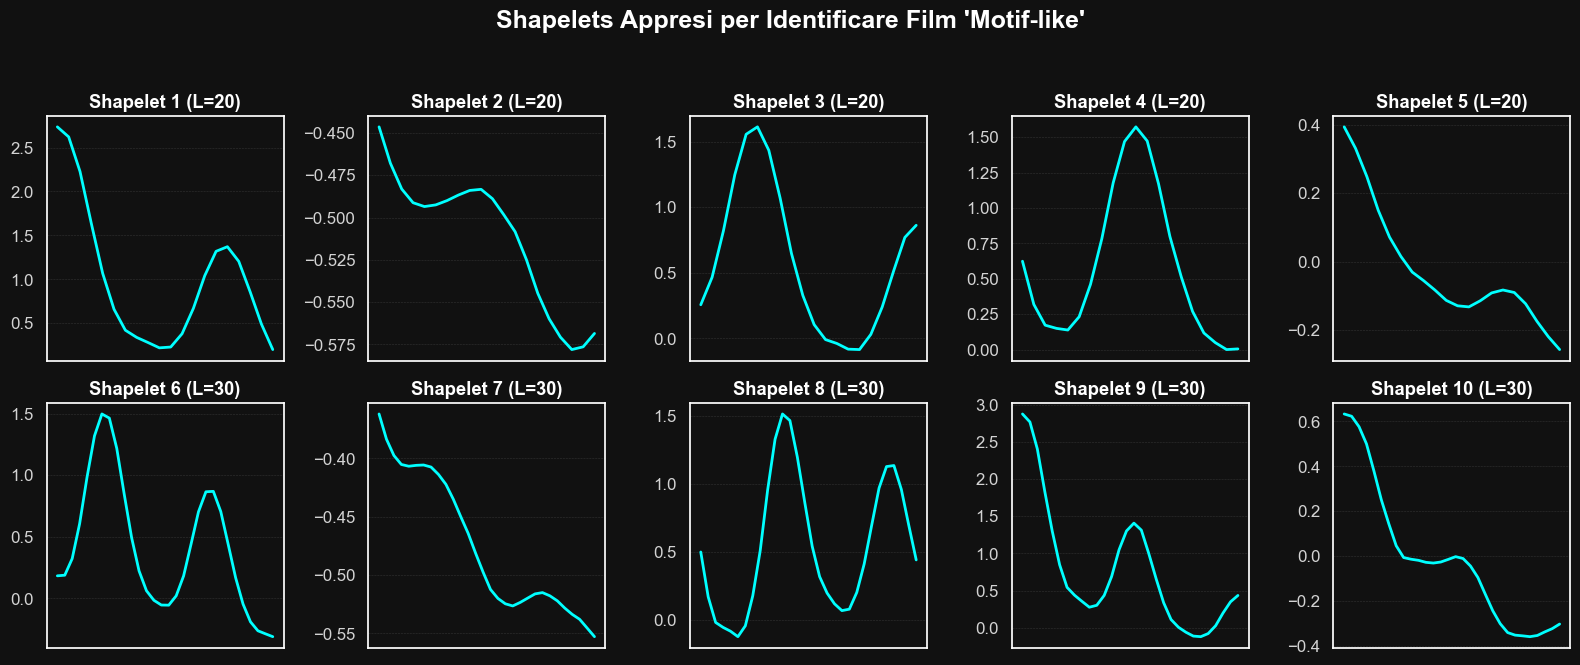

✅ Grafico degli shapelets salvato in: plots_time_series_motifs_discords/shapelets_motif_like.png


In [7]:
# =================================================================================
# CELLA 4 (Definitiva): Shapelet Discovery per il "Motif-like" e Valutazione
# =================================================================================
#
# --- OBIETTIVO ---
# Isolare i film "motif-like" (Action & Drama) e trovare la loro "firma" temporale.
# ---------------------------------------------------------------------------------
import ast
from tslearn.shapelets import ShapeletModel
from sklearn.metrics import classification_report, confusion_matrix

# 1. PREPARAZIONE DATI (locale a questa cella)
# ---------------------------------------------------------------------------------
print("--- [Step 1/5] Preparazione dati per l'analisi Shapelet ---")

# Creiamo una copia LOCALE di 'metadata' per lavorarci sopra in sicurezza
df_shapelet = metadata.copy()

# Convertiamo la colonna 'genre' da stringa a lista di generi
try:
    df_shapelet['genre_list'] = df_shapelet['genre'].apply(ast.literal_eval)
except Exception as e:
    print(f"❌ ERRORE nella conversione della colonna 'genre': {e}")
    exit(1)

# Definiamo i generi che caratterizzano il nostro motivo
TARGET_GENRES_MOTIF = ['Action', 'Drama']

# Funzione per etichettare i film: 1 se contiene TUTTI i generi target, altrimenti 0
def is_motif_like(genres):
    return int(all(g in genres for g in TARGET_GENRES_MOTIF))

# Applichiamo la funzione per creare la nostra colonna target
df_shapelet['motif_like'] = df_shapelet['genre_list'].apply(is_motif_like)
print(f"✅ Etichetta 'motif_like' creata per i generi {TARGET_GENRES_MOTIF}.")


# 2. PREPARAZIONE DI X e y
# ---------------------------------------------------------------------------------
print("\n--- [Step 2/5] Preparazione di X e y per il modello ---")

X_train_motif = ts_std.copy()
y_train_motif = df_shapelet['motif_like'].to_numpy()

if X_train_motif.ndim == 2:
    X_train_motif = X_train_motif.reshape((X_train_motif.shape[0], X_train_motif.shape[1], 1))

print(f"   Distribuzione: {df_shapelet['motif_like'].value_counts().to_dict()}")

# 3. ADDESTRAMENTO DEL MODELLO SHAPELET
# ---------------------------------------------------------------------------------
print(f"\n--- [Step 3/5] Addestramento del modello Shapelet in corso... ---")
start_time = time.time()

shapelet_model_motif = ShapeletModel(n_shapelets_per_size={20: 5, 30: 5}, max_iter=200, random_state=42)
shapelet_model_motif.fit(X_train_motif, y_train_motif)
end_time = time.time()
print(f"✅ Addestramento completato in {end_time - start_time:.2f} secondi.")

# 4. VALUTAZIONE DELLE PERFORMANCE DEL MODELLO
# ---------------------------------------------------------------------------------
print("\n--- [Step 4/5] Valutazione delle performance del modello ---")

y_pred_motif = shapelet_model_motif.predict(X_train_motif)

print("\n--- Matrice di Confusione ---")
cm = confusion_matrix(y_train_motif, y_pred_motif)
print("Spiegazione (riga=Reale, colonna=Previsto):")
print(f"        | Prev. Non-Motif | Prev. Motif-Like |")
print(f"Reale Non-Motif |    {cm[0][0]:<8}     |    {cm[0][1]:<8}      |")
print(f"Reale Motif-Like|    {cm[1][0]:<8}     |    {cm[1][1]:<8}      |")

print("\n--- Report di Classificazione ---")
class_names = ['Non-Motif-Like', 'Motif-Like']
print(classification_report(y_train_motif, y_pred_motif, target_names=class_names))

# 5. VISUALIZZAZIONE DEGLI SHAPELETS "MOTIF-LIKE"
# ---------------------------------------------------------------------------------
print(f"\n--- [Step 5/5] Visualizzazione degli Shapelets per film 'Action/Drama' ---")

learned_shapelets_motif = shapelet_model_motif.shapelets_

plt.figure(figsize=(16, 7))
plt.suptitle(f"Shapelets Appresi per Identificare Film 'Motif-like'", fontsize=18, weight='bold')

for i, shp in enumerate(learned_shapelets_motif):
    ax = plt.subplot(2, 5, i + 1)
    ax.plot(shp.ravel(), color='cyan', lw=2)
    ax.set_title(f'Shapelet {i+1} (L={len(shp)})')
    plt.xticks([])

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
shapelets_plot_path = os.path.join(plots_dir, 'shapelets_motif_like.png')
plt.savefig(shapelets_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico degli shapelets salvato in: {shapelets_plot_path}")

--- Creazione del grafico riassuntivo (Motifs & Discord vs. Media) ---


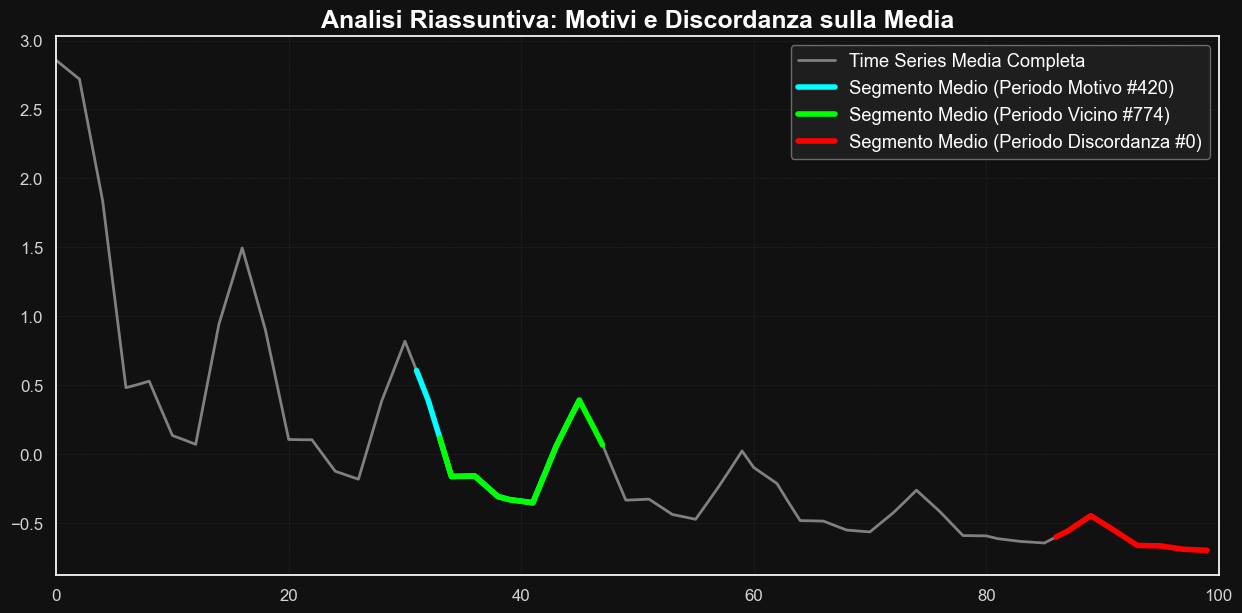

✅ Grafico riassuntivo salvato in: plots_time_series_motifs_discords/summary_mean_vs_motifs_discords.png


In [8]:
# =================================================================================
# GRAFICO FINALE: MOTIFS & DISCORDS SULLA TIME SERIES MEDIA
# =================================================================================

print("--- Creazione del grafico riassuntivo (Motifs & Discord vs. Media) ---")

# 1. CALCOLO DELLA TIME SERIES MEDIA
# ---------------------------------------------------------------------------------
mean_ts = ts_std.mean(axis=0)

# 2. CREAZIONE DEL GRAFICO COMPLETO
# ---------------------------------------------------------------------------------
plt.figure(figsize=(15, 7))
plt.title('Analisi Riassuntiva: Motivi e Discordanza sulla Media', fontsize=18, weight='bold')

# Disegniamo l'intera time series media come sfondo
plt.plot(mean_ts, color='gray', lw=2, label='Time Series Media Completa')

# --- EVIDENZIAMO I SEGMENTI DEI MOTIVI ---
# Estraiamo e disegniamo il segmento della media nel periodo del primo motivo
motif_window_on_mean = mean_ts[motif_sub_idx : motif_sub_idx + m]
plt.plot(range(motif_sub_idx, motif_sub_idx + len(motif_window_on_mean)),
         motif_window_on_mean,
         color='cyan',
         lw=4,
         label=f'Segmento Medio (Periodo Motivo #{motif_ts_idx})')

# Estraiamo e disegniamo il segmento della media nel periodo del vicino
neighbor_window_on_mean = mean_ts[neighbor_sub_idx : neighbor_sub_idx + m]
plt.plot(range(neighbor_sub_idx, neighbor_sub_idx + len(neighbor_window_on_mean)),
         neighbor_window_on_mean,
         color='lime',
         lw=4,
         label=f'Segmento Medio (Periodo Vicino #{neighbor_ts_idx})')

# --- AGGIUNTA: EVIDENZIAMO IL SEGMENTO DELLA DISCORDANZA ---
# Estraiamo e disegniamo il segmento della media nel periodo della discordanza
discord_window_on_mean = mean_ts[discord_sub_idx : discord_sub_idx + m]
plt.plot(range(discord_sub_idx, discord_sub_idx + len(discord_window_on_mean)),
         discord_window_on_mean,
         color='red',
         lw=4,
         label=f'Segmento Medio (Periodo Discordanza #{discord_ts_idx})')


# 3. FINALIZZAZIONE DEL GRAFICO
# ---------------------------------------------------------------------------------
plt.xlim(0, ts_std.shape[1])
plt.legend()
plt.grid(True, alpha=0.2)

# Salvataggio del grafico
summary_plot_path = os.path.join(plots_dir, 'summary_mean_vs_motifs_discords.png')
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico riassuntivo salvato in: {summary_plot_path}")